### Пет-проект: A/B-тест персонализированной системы рекомендации товаров

- Сайт с которого взял датасет: [Ссылка](https://ab-tests.ru)
- Ключ к данным для доступа и проверки метрик: 999543812

In [1]:
# Загружаем все необходимые библиотеки для выполнения проекта
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [53]:
# Первый взгляд на данные
df_transactions = pd.read_csv('transactions.csv')
df_users = pd.read_csv('users.csv')
display(df_transactions.head())
display(df_users.head())

,id,amount,date
0,0007baa91954971526e2c2afbf029a58,3864.0,2024-04-28
1,0007da0d99bdd6ae64c6860c2a7a52dd,5649.0,2024-04-25
2,000fb97df01782421d2666674f16f0c7,6119.0,2024-04-26
3,0016d807a4f2269a59f67ab8e9d9861e,1082.0,2024-04-25
4,00191029f816b6dacf06f011e9b0f52d,14434.0,2024-04-26


,id,group
0,692c3697f26f444268b6d2389332b31f,control
1,bfd90360060d34af4f7481e4d90837e4,control
2,f1b85853b6208f53a3e70f76f87a6bc2,control
3,813738d5ccbe5f61b83f0da19cea12d2,control
4,91cc087093c2fb2179db01a1cadfed50,control


In [60]:
# Быстрая проверка данных таблицы транзакций
print(df_transactions.shape)
print(df_transactions.dtypes)
print(df_transactions.isna().sum())
print(df_transactions.duplicated().sum())

(18770, 3)
id            str
amount    float64
date          str
dtype: object
id        0
amount    0
date      0
dtype: int64
0


In [61]:
# Быстрая проверка данных таблицы юзеров
print(df_users.shape)
print(df_users.dtypes)
print(df_users.isna().sum())
print(df_users.duplicated().sum())

(83470, 2)
id       str
group    str
dtype: object
id       0
group    0
dtype: int64
0


In [62]:
# Проверяем баланс групп: реально ли было разделение пользователей 50% на 50:
amount_group = len(df_users)
control_group_cnt = len(df_users[df_users['group'] == 'control'])
treatment_group_cnt = len(df_users[df_users['group'] == 'treatment'])

print(f"total amount: {amount_group}")
print(f"control: {control_group_cnt} treatment: {treatment_group_cnt}")
print(f"control: {round((control_group_cnt / amount_group) * 100, 2)}% treatment: {round((treatment_group_cnt / amount_group) * 100, 2)}%")



total amount: 83470
control: 42029 treatment: 41441
control: 50.35% treatment: 49.65%


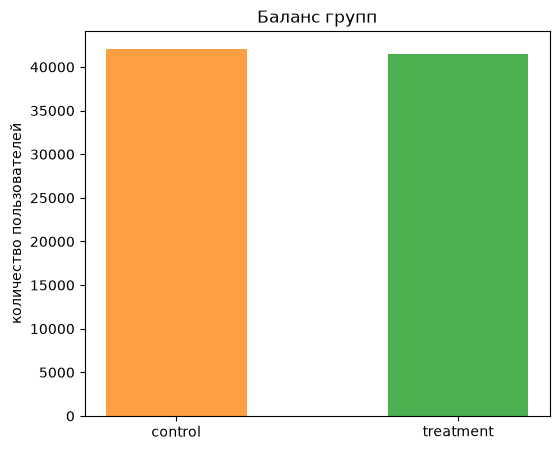

In [84]:
# Для наглядности решил сделать bar chart
groups = ['control', 'treatment']
counts = [control_group_cnt, treatment_group_cnt ]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(groups, counts, color=["#ff9f43", "#4caf50"], width=0.5)

ax.set_ylabel('количество пользователей')
ax.set_title('Баланс групп')
plt.show()


In [63]:
# Проверка, что нет отрицательных значений в столбце amount
print((df_transactions['amount'] < 0).sum())

0


In [7]:
# определяем выбросы
df_sorted = df_transactions.sort_values('amount')
quartiles = df_sorted['amount'].quantile([0.25, 0.5, 0.75])
iqr = quartiles[0.75] - quartiles[0.25]
print(f"IQR: {iqr}")
lower_bound = quartiles[0.25] - 1.5 * iqr
high_bound = quartiles[0.75] + 1.5 * iqr
print(f"lower bound: {lower_bound} ", f"upper bound: {high_bound}", sep='\n')
anomalies = len(df_sorted[df_sorted['amount'] > high_bound])
print(f"number of anomalous results {anomalies}")


IQR: 3529.0
lower bound: -1701.5 
upper bound: 12414.5
number of anomalous results 404


In [8]:
# следующий шаг посоветоваться с клаудом и сокрее всего удалить аномальные значения

In [9]:
print(df_sorted[df_sorted['amount'] > high_bound])
# тут нужно понять одинаковые ли большие значения в тестовой и контрольной группе. Если они одинаковые, то мы их оставляем. Если они разные, то все-таки это выбросы и их нужно удалить

                                     id   amount        date
13657  bb36af167b028804cab3202cb549983c  12415.0  2024-04-24
14385  c50cbe64e20883ec2d90bf1d69935ef0  12418.0  2024-04-24
17715  f1dcdc68e88b16e5d78b1ef27e3e6a88  12426.0  2024-04-23
9837   8705a1256d116e1e0f0ebeea41de47c7  12430.0  2024-04-27
12647  ace17cea9c7957adebb6a555747d6473  12433.0  2024-04-23
...                                 ...      ...         ...
17987  f56ca82f836e9ecfa1d1195fafb44cd0  20191.0  2024-04-28
16559  e26885f53019bf7e54c9b7cc202ccc3b  20527.0  2024-04-28
15562  d54abec4d3e60a42e2ebe04835d8959f  20707.0  2024-04-25
2971   28493e914916ee59683ea54485277a28  21055.0  2024-04-24
10909  955e5dd4fe0f2624a715293176aa5ed1  22647.0  2024-04-27

[404 rows x 3 columns]


In [44]:
# объединить два датафрейма чтобы после посмотерть то что написано выше
df_join = df_users.merge(df_transactions, how = 'left', on='id')
df_join = df_join.sort_values('amount')
df_users_control = df_join[(df_join['group'] == 'control') & (df_join['amount'] > high_bound)]
df_users_treatment = df_join[(df_join['group'] == 'treatment') & (df_join['amount'] > high_bound)]
df_users_control_cnt = len(df_users_control)
df_users_treatment_cnt = len(df_users_treatment)
print(df_users_control_cnt, df_users_treatment_cnt)

# Как мы вижим ольшие значение распределены равномерно, поэтому их можно не удалять и дальше работать с ними
display(df_join)




187 217


,id,group,amount,date
30261,ab1634456e718bbe4b0c910d22ff838c,control,273.0,2024-04-29
71467,0664cb8e543379a038fc816ac668faec,treatment,394.0,2024-04-29
334,d70ae7fc9b9811053d8c285fc30f2be3,control,401.0,2024-04-28
80100,3eab83f0cfad383cee2df18f4498f7cb,treatment,445.0,2024-04-23
69592,2338b8018b1005b5840ac63cf186de95,treatment,471.0,2024-04-25
...,...,...,...,...
83465,41b6d36f39add720486bfa5686b6a6e1,treatment,NaN,NaN
83466,9251ac83769a483dcf04680eecf44b43,treatment,NaN,NaN
83467,7485f4682b371b90be9bd2171809321a,treatment,NaN,NaN
83468,ffadeba0298d68e7c9ab428d55b812f5,treatment,NaN,NaN


In [45]:
# сейчас нам нужно расчитать метрики вовлеченностии и средний чек по пользователю
# метрику воволеченности будем счиатать как число транзакций на пользователя за 7 дней

# соотвественно начинаем рассчитывать метрику вовлеченности

# я хочу расписать метрику вовлеченнсти, то есть посмотреть количество покупок у пользователей группы control и группы treatment

# вроде данные укладываются в 7 дневный таймлайн, но мы все равно чекнем

df_join['date'] = pd.to_datetime(df_join['date'])

#print(df_join['date'].min, df_join['date'].max)
print((df_join['date'].max() - df_join['date'].min()).days)

6


In [46]:
# если считать метрику вовлеченности ER, то получается такая формула
# ER_group = (количество транзакций в группе) / (количество пользователей в группе ) * 100%
pd_for_er_metric = (
    df_join.groupby(by='group')
    .agg(
        transactions=('amount', 'count'),
        users=('id','nunique')
    )
)
display(pd_for_er_metric)


,transactions,users
group,,
control,8855,42029
treatment,9915,41441


In [47]:
er_metric = (pd_for_er_metric['transactions'] / pd_for_er_metric['users']) * 100
display(er_metric)


group
control      21.068786
treatment    23.925581
dtype: float64

In [48]:
# Теперь считаем срений чек по пользователю
avg_check_per_user = (
    df_join
    .groupby(by=['group', 'id'])['amount'].mean()
    .reset_index(name='user_avg_check')
    .groupby('group')['user_avg_check']
    .mean()
)
display(avg_check_per_user)

group
control      5512.281988
treatment    5656.643268
Name: user_avg_check, dtype: float64

In [49]:
# применяем статистический критерий
# применим t-test к посчитанным метрикам
control = df_join[df_join['group'] == 'control']['amount'].values
treatment = df_join[df_join['group'] == 'treatment']['amount'].values
# считаем разницу средних
delta_mean = np.mean(treatment) - np.mean(control)
print(f"delta_mean={delta_mean}")
stats.ttest_ind(control, treatment)

delta_mean=nan


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [ ]:
# Получается, что альфа > p-value и мы делаем вывод, что разница статистически значима